# Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# Load Data

In [ ]:
data = pd.read_csv('/content/otu_genus_clr_prevfiltered-hp.csv')
binary = pd.read_csv('/content/sample_metadata_binary-hp.csv')

In [ ]:
data.head()

,Sample_ID,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,P001Z12,1.136165,5.666962,-1.329606,5.125296,3.407573,2.507664,5.543468,3.427601,-1.329606,...,2.675229,3.262707,7.029766,-1.329606,-1.329606,2.243472,-1.329606,6.580870,6.379528,5.467354
1,P001Z13,-0.348473,6.435700,0.393300,2.158804,3.982938,-1.146599,2.089231,4.501488,3.738455,...,0.896899,0.814463,7.661200,-0.348473,3.209424,-0.105595,2.686182,6.275081,6.072512,4.416165
2,P001Z14,1.367808,5.945386,0.072880,3.663450,3.124310,-1.512935,4.293321,3.337950,3.367871,...,-1.512935,2.748320,7.190134,-1.512935,2.652594,-1.512935,1.913662,5.645632,6.106997,5.556124
3,P001Z18,4.143998,5.634243,2.947621,3.197061,2.785120,-0.737450,3.665411,2.930816,2.287356,...,-1.140968,2.203289,7.952309,-1.140968,2.626075,-1.140968,1.656895,6.257157,6.162395,4.278155
4,P002Z18,2.350095,3.820098,-1.238502,6.664077,-1.238502,2.943589,6.037687,-1.238502,-1.238502,...,3.483684,5.517361,6.830796,-1.238502,-1.238502,-1.238502,-1.238502,7.214300,3.880349,-1.238502


In [ ]:
data.shape

(29, 61)

In [ ]:
binary.head()

,Sample_ID,Hp_Status_binary,label_binary,Hp_CagA_Status,Score
0,P001Z12,H.p.-,0,H.p.-,not aplicable
1,P001Z13,H.p.-,0,H.p.-,not aplicable
2,P001Z14,H.p.-,0,H.p.-,not aplicable
3,P001Z18,H.p.-,0,H.p.-,not aplicable
4,P002Z18,H.p.-,0,H.p.-,not aplicable


In [ ]:
binary.shape

(29, 5)

Join Data and Binary Dataframes

In [ ]:
df = pd.merge(data, binary[['Sample_ID', 'label_binary']], on='Sample_ID')

In [ ]:
df.shape

(29, 62)

In [ ]:
df.to_csv('data.csv')

Separate X and Y dataframes

In [ ]:
X = df.drop(['Sample_ID', 'label_binary'], axis=1)
y = df['label_binary']

## Apply Data Augmentation

En esta etapa se aplica un proceso de aumento de datos (*data augmentation*) con el objetivo de mejorar la calidad y cantidad del dataset original, el cual cuenta con un número muy reducido de observaciones. Primero, se realiza una estandarización de las variables utilizando `StandardScaler`, lo que permite que todas las características tengan media cero y desviación estándar uno. Este paso es fundamental en modelos basados en redes neuronales, ya que evita que variables con diferentes escalas dominen el proceso de aprendizaje. Posteriormente, se aplica la técnica **SMOTE (Synthetic Minority Over-sampling Technique)**, configurada para generar un total de 40 muestras por cada clase, lo que permite balancear completamente el dataset y aumentar su tamaño de manera controlada a partir de ejemplos sintéticos coherentes con la distribución original.

Adicionalmente, se introduce una pequeña cantidad de ruido gaussiano sobre los datos generados, lo que permite incrementar la variabilidad del dataset sin alterar significativamente su estructura. Este proceso ayuda a mejorar la capacidad de generalización del modelo al exponerlo a ligeras variaciones de los datos. Como resultado, el dataset pasa de tener 29 observaciones a un total de 80, manteniendo la coherencia entre las variables. Finalmente, los datos aumentados son convertidos nuevamente a un DataFrame para conservar la estructura original y facilitar su posterior uso en el entrenamiento y evaluación del modelo.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
smote = SMOTE(sampling_strategy={0: 40, 1: 40}, k_neighbors=3, random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

Noise

In [ ]:
noise = np.random.normal(0, 0.01, X_res.shape)
X_aug = X_res + noise

In [ ]:
print("Original:", X.shape)
print("Aumentado:", X_aug.shape)

Original: (29, 60)
Aumentado: (80, 60)


In [ ]:
X_aug = pd.DataFrame(X_aug, columns=X.columns)

In [ ]:
X_aug.head()

,Actinobacillus,Actinomyces,Aggregatibacter,Alkalibacterium,Atopobium,Bacillus,Bacteroides,Bulleidia,Campylobacter,Capnocytophaga,...,Staphylococcus,Stenotrophomonas,Streptococcus,TG5,Tannerella,Thiobacillus,Treponema,Unclassified,Veillonella,[Prevotella]
0,0.863816,0.985573,-1.049317,1.564695,0.661749,2.487960,1.732750,0.896304,-1.591278,-1.296946,...,1.727232,0.950705,0.905826,-0.962488,-1.258798,2.452091,-1.309213,1.116997,1.160563,1.082071
1,-0.288030,1.386448,0.451905,-0.840566,0.964275,-0.997208,-0.953456,1.590076,1.315987,2.034381,...,0.332760,-1.041486,1.307623,-0.091490,1.583510,0.060617,0.842542,0.841724,0.949867,0.556506
2,1.039111,1.129928,0.168814,0.400864,0.503968,-1.328692,0.754004,0.832957,1.100825,1.339777,...,-1.550243,0.547107,0.994234,-1.113479,1.241390,-1.384838,0.431345,0.308722,0.995916,1.130071
3,3.124626,0.979046,2.614041,0.018511,0.329455,-0.612545,0.269476,0.584902,0.481644,1.046469,...,-1.253233,0.094159,1.494822,-0.807358,1.227553,-1.004332,0.287841,0.819296,1.014956,0.496258
4,1.763008,-0.044492,-0.956081,2.849244,-1.867715,2.916700,2.119127,-2.123492,-1.521777,-1.260459,...,2.371132,2.824197,0.767368,-0.882017,-1.214368,-1.127388,-1.266461,1.646999,-0.339165,-2.291959


# Autoencoder

En esta sección se implementa un autoencoder con el objetivo de aprender una representación comprimida de los datos de entrada. Inicialmente, se define la dimensión de entrada (`input_dim`), correspondiente al número de características del dataset, y se establece una dimensión reducida (`encoding_dim = 8`) que determina el tamaño del espacio latente. Posteriormente, se construye la arquitectura del modelo utilizando la API funcional, donde el **encoder** está compuesto por una capa densa con función de activación ReLU que transforma los datos originales en una representación más compacta. A continuación, el **decoder** reconstruye la información original a partir de dicha representación mediante una capa densa con activación lineal, permitiendo generar una salida con la misma dimensionalidad que la entrada.

El modelo completo se define conectando la capa de entrada con la salida reconstruida, y se entrena utilizando el optimizador Adam junto con la función de pérdida de error cuadrático medio (MSE), la cual mide la diferencia entre los datos originales y los reconstruidos. Durante el entrenamiento, el autoencoder recibe como entrada y salida el mismo conjunto de datos, lo que le permite aprender la estructura interna del dataset de manera no supervisada. El proceso se lleva a cabo durante 50 épocas, utilizando un tamaño de lote de 16 y validando el desempeño con el conjunto de prueba.

In [ ]:
def train_and_evaluate_autoencoder(X, y):
    """
    Entrena y evalúa un autoencoder en el dataset original.

    Args:
        X (pd.DataFrame): DataFrame de características.
        y (pd.Series): Serie de etiquetas.

    Returns:
        tensorflow.keras.models.Model: El autoencoder entrenado.
        tensorflow.keras.models.Model: El modelo encoder.
        tensorflow.python.framework.ops.Tensor: El tensor `decoded`.
        pd.DataFrame: Conjunto de entrenamiento de características.
        pd.Series: Conjunto de entrenamiento de etiquetas.
        pd.DataFrame: Conjunto de prueba de características.
        pd.Series: Conjunto de prueba de etiquetas.
    """
    # Separar datos en conjuntos de entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Definir la arquitectura del autoencoder
    input_dim = X_train.shape[1]
    encoding_dim = 8  # ajustable

    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
    decoded = layers.Dense(input_dim, activation='linear')(encoded)

    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    print("\n--- Entrenando Autoencoder ---")
    history_ae = autoencoder.fit(X_train, X_train,
                                epochs=50,
                                batch_size=16,
                                validation_data=(X_test, X_test),
                                verbose=0)
    print("Entrenamiento completado.")

    # Gráfica de la pérdida del autoencoder
    plt.figure(figsize=(10, 5))
    plt.plot(history_ae.history['loss'], label='Train Loss')
    plt.plot(history_ae.history['val_loss'], label='Validation Loss')
    plt.title('Autoencoder Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Gráfica de pérdida del autoencoder generada.")

    # Calcular y graficar el error de reconstrucción
    X_pred = autoencoder.predict(X_test)
    mse = np.mean(np.power(X_test - X_pred, 2), axis=1)

    plt.figure(figsize=(10, 5))
    plt.hist(mse, bins=50)
    plt.title('Reconstruction Error')
    plt.xlabel('MSE')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()
    print("Histograma de error de reconstrucción generado.")

    # Crear el modelo encoder
    encoder_model_obj = models.Model(input_layer, encoded)

    return autoencoder, encoder_model_obj, decoded, X_train, y_train, X_test, y_test

## Original Dataset


--- Entrenando Autoencoder ---
Entrenamiento completado.


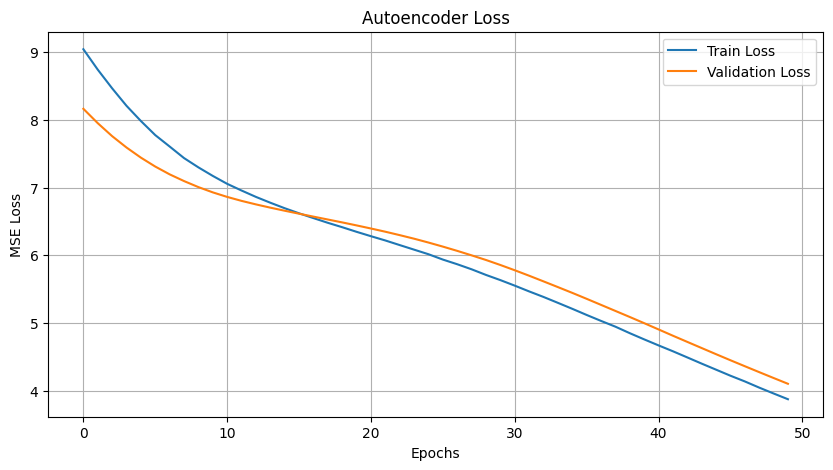

Gráfica de pérdida del autoencoder generada.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


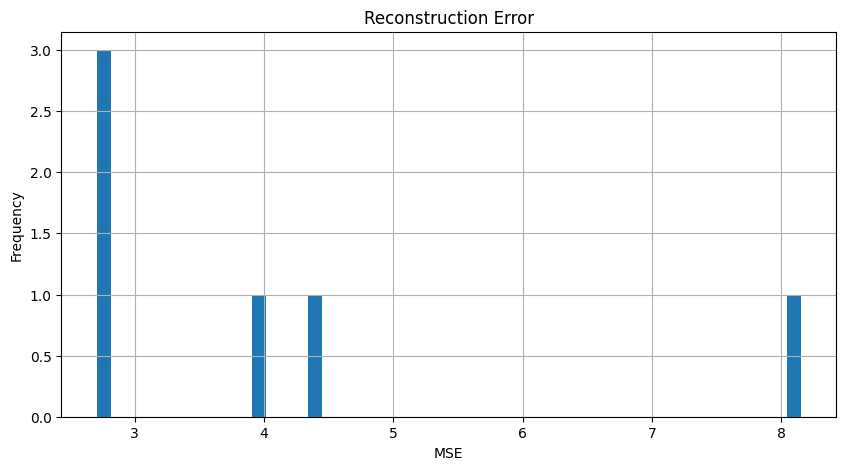

Histograma de error de reconstrucción generado.

Autoencoder para el dataset original entrenado y evaluado.


In [ ]:
# Llamar a la función con el dataset original
original_trained_autoencoder, original_encoder_model, original_decoder_model, X_train_original, y_train_original, X_test_original, y_test_original = train_and_evaluate_autoencoder(X, y)

print("\nAutoencoder para el dataset original entrenado y evaluado.")

La gráfica de pérdida del autoencoder muestra la evolución del error de reconstrucción tanto en el conjunto de entrenamiento como en el de validación a lo largo de las épocas. Esta métrica permite evaluar qué tan bien el modelo está aprendiendo a reconstruir los datos originales.

Una disminución progresiva en ambas curvas indica que el modelo está capturando adecuadamente los patrones presentes en los datos. Si las curvas de entrenamiento y validación se mantienen cercanas, se puede inferir que el modelo generaliza correctamente. Por el contrario, una separación significativa entre ambas podría indicar sobreajuste, mientras que una falta de disminución en la pérdida sugiere que el modelo no está aprendiendo de manera efectiva.


Posteriormente, se calcula el error de reconstrucción sobre el conjunto de prueba comparando los valores originales con los generados por el autoencoder. Para ello, se obtiene la predicción del modelo (`X_pred`) y se calcula el error cuadrático medio por cada muestra. Este valor representa qué tan bien el modelo es capaz de reconstruir cada observación individual.

El histograma del error de reconstrucción permite analizar la distribución de estos errores en el dataset. Valores bajos indican que el modelo reconstruye correctamente la mayoría de los datos, mientras que valores altos pueden señalar observaciones más complejas o incluso posibles outliers. Esta gráfica proporciona una visión más detallada del desempeño del autoencoder, complementando la información obtenida a partir de la función de pérdida global.

## Augmented Dataset


--- Entrenando Autoencoder ---
Entrenamiento completado.


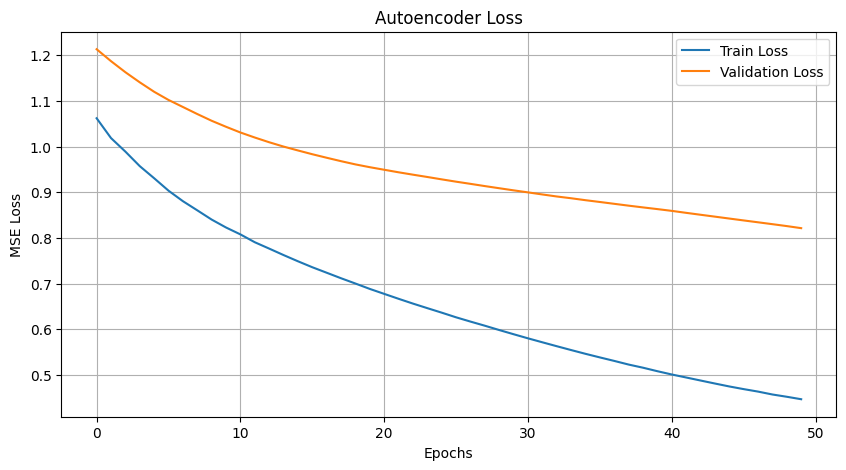

Gráfica de pérdida del autoencoder generada.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


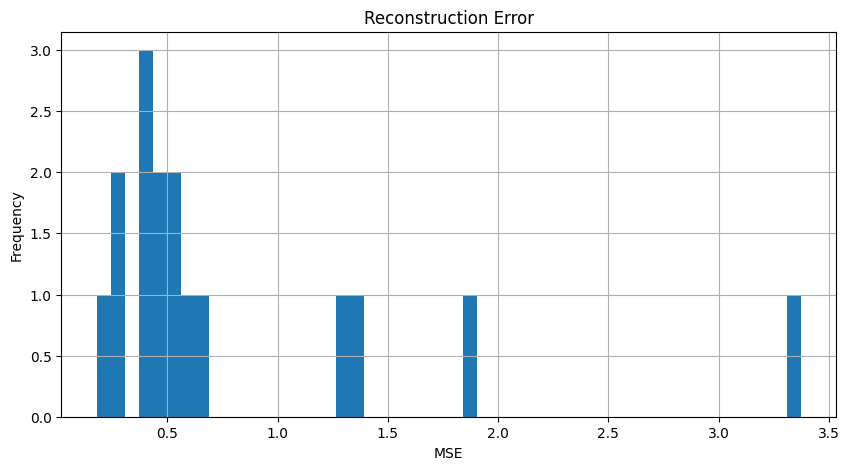

Histograma de error de reconstrucción generado.


In [ ]:
augmented_trained_autoencoder, augmented_encoder_model, augmented_decoder_model,X_train_augmented, y_train_augmented, X_test_augmented, y_test_augmented = train_and_evaluate_autoencoder(X_aug, y_res)

# Extract Encoder

In [ ]:
def visualize_latent_space(encoder_model, X_test_data, y_test_data):
    """
    Genera y visualiza la representación del espacio latente.

    Args:
        encoder_model (tensorflow.keras.models.Model): El modelo encoder entrenado.
        X_test_data (pd.DataFrame): Datos de prueba.
        y_test_data (pd.Series): Etiquetas de prueba.
    """
    encoded_data = encoder_model.predict(X_test_data)

    plt.figure(figsize=(10, 8))
    plt.scatter(encoded_data[:, 0], encoded_data[:, 1], c=y_test_data, cmap='viridis')
    plt.colorbar(label='label_binary')
    plt.title('Latent Space Representation')
    plt.xlabel('Z1')
    plt.ylabel('Z2')
    plt.grid(True)
    plt.show()
    print("Gráfica de representación del espacio latente generada.")


Una vez entrenado el autoencoder, se procede a extraer únicamente la parte correspondiente al **encoder**, eliminando el decoder. Esto se realiza con el objetivo de utilizar el encoder como un modelo independiente capaz de transformar los datos originales en una representación comprimida dentro del espacio latente. De esta manera, el encoder actúa como un **extractor de características**, generando una nueva representación de los datos que captura las relaciones más relevantes aprendidas durante el entrenamiento no supervisado.

Posteriormente, se aplica el encoder sobre el conjunto de prueba (`X_test`) para obtener los datos codificados (`encoded_data`). Estos valores corresponden a la representación en el espacio latente, el cual tiene una dimensionalidad reducida en comparación con el espacio original. En este caso, al trabajar con dos dimensiones latentes, es posible visualizar directamente esta transformación mediante un gráfico de dispersión.

La gráfica del espacio latente muestra cómo el modelo organiza los datos en la nueva representación aprendida. Cada punto corresponde a una muestra del dataset transformada por el encoder, y el color indica su clase real (`label_binary`).

Esta visualización permite evaluar la calidad de la representación aprendida:

- Si las clases aparecen claramente separadas, significa que el encoder ha logrado capturar patrones discriminativos relevantes.
- Si los puntos de diferentes clases se encuentran mezclados, indica que la representación no es suficientemente informativa para tareas de clasificación.
- La formación de agrupaciones o clusters sugiere que el modelo ha identificado estructuras internas en los datos.

En conjunto, esta gráfica es una herramienta clave para entender cómo el autoencoder está organizando la información y qué tan útil será esta representación para la etapa posterior de clasificación.

## Original Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


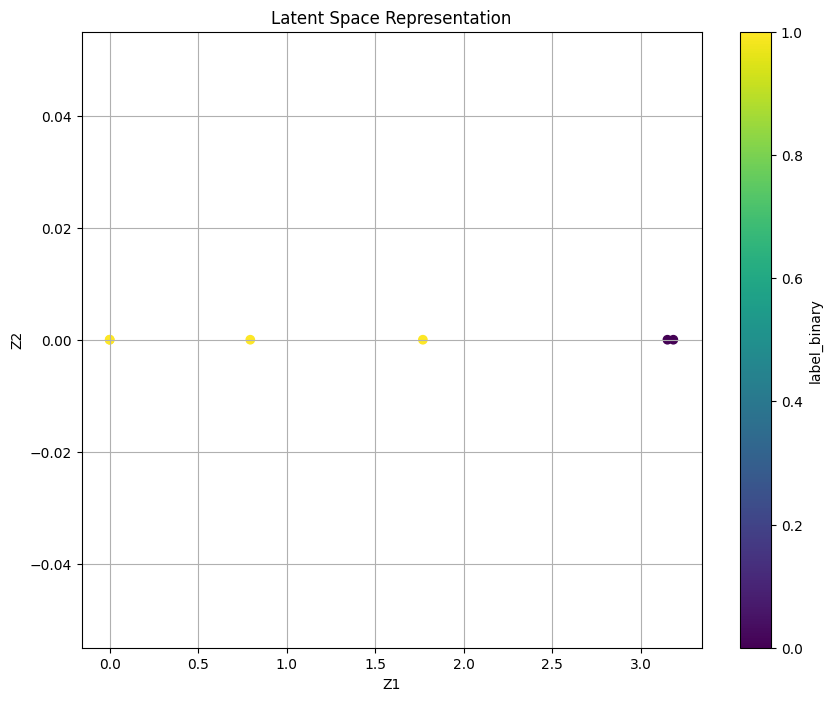

Gráfica de representación del espacio latente generada.


In [ ]:
visualize_latent_space(original_encoder_model, X_test_original, y_test_original)

## Augmented Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


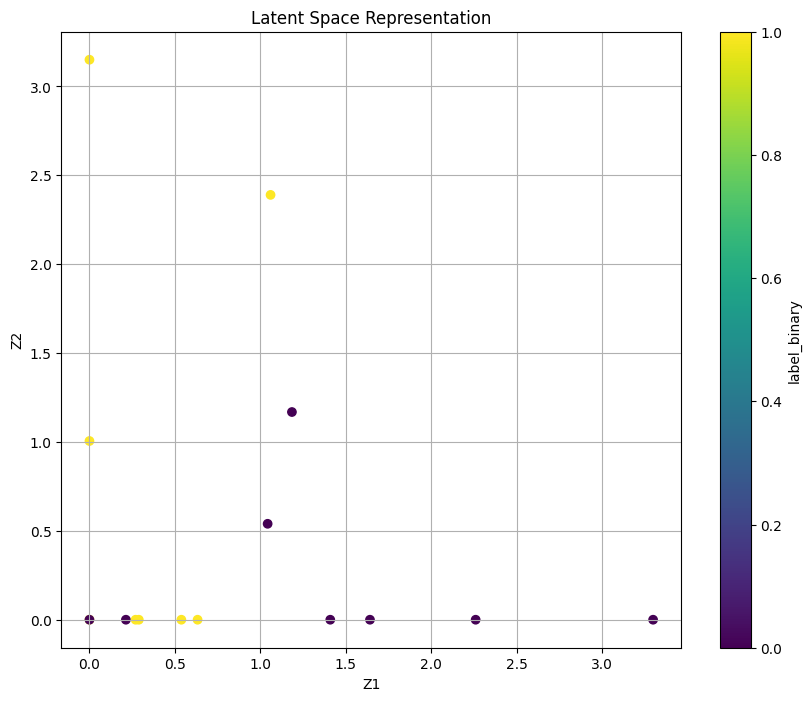

Gráfica de representación del espacio latente generada.


In [ ]:
visualize_latent_space(augmented_encoder_model, X_test_augmented, y_test_augmented)

# Shallow Clasificator

In [ ]:
def train_and_evaluate_classifier(encoder_model, X_train_data, y_train_data, X_test_data, y_test_data):
    """
    Construye, entrena y evalúa un clasificador superficial utilizando un encoder.

    Args:
        encoder_model (tensorflow.keras.models.Model): El modelo encoder entrenado.
        X_train_data (pd.DataFrame): Características de entrenamiento.
        y_train_data (pd.Series): Etiquetas de entrenamiento.
        X_test_data (pd.DataFrame): Características de prueba.
        y_test_data (pd.Series): Etiquetas de prueba.
    """
    print("\n--- Entrenando Clasificador Superficial ---")

    # Define el input para el clasificador, que es el mismo que el input del encoder
    classifier_input = encoder_model.input

    # Pasa el input a través del encoder_model para obtener sus características codificadas
    encoded_features = encoder_model(classifier_input)

    # Añade la capa de clasificación sobre las características codificadas
    output = layers.Dense(1, activation='sigmoid')(encoded_features)  # binario

    # Crea el modelo clasificador completo
    classifier = models.Model(inputs=classifier_input, outputs=output)

    classifier.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

    history_clf = classifier.fit(X_train_data, y_train_data,
                   epochs=50,
                   batch_size=16,
                   validation_data=(X_test_data, y_test_data),
                   verbose=0)
    print("Entrenamiento del clasificador completado.")

    # Gráfica de la precisión del clasificador
    plt.figure(figsize=(10, 5))
    plt.plot(history_clf.history['accuracy'], label='Train Accuracy')
    plt.plot(history_clf.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Classifier Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("Gráfica de precisión del clasificador generada.")

    # Matriz de confusión
    y_pred = (classifier.predict(X_test_data) > 0.5).astype(int)

    cm = confusion_matrix(y_test_data, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title('Confusion Matrix')
    plt.show()
    print("Matriz de confusión generada.")

    return classifier


En esta etapa se construye un modelo de clasificación utilizando el encoder previamente entrenado como base. En lugar de trabajar directamente con los datos originales, el modelo utiliza la representación comprimida generada por el encoder, la cual contiene las características más relevantes del dataset. Sobre esta representación, se añade una única capa densa con función de activación sigmoide, adecuada para problemas de clasificación binaria, permitiendo obtener una probabilidad asociada a cada clase.

El modelo resultante corresponde a una **red neuronal superficial (shallow)**, ya que únicamente incorpora una capa de salida adicional sobre el encoder. Este enfoque combina aprendizaje no supervisado (autoencoder) con aprendizaje supervisado (clasificación), permitiendo aprovechar las representaciones aprendidas previamente. El modelo se entrena utilizando el optimizador Adam y la función de pérdida de entropía cruzada binaria (*binary crossentropy*), optimizando la capacidad de predicción sobre la variable objetivo `label_binary`.


La matriz de confusión permite analizar en detalle el desempeño del modelo comparando las predicciones con los valores reales. Cada celda indica la cantidad de aciertos o errores en cada clase.

- Verdaderos positivos y verdaderos negativos representan predicciones correctas.
- Falsos positivos y falsos negativos indican errores del modelo.

Esta herramienta es especialmente útil para identificar en qué tipo de clase el modelo presenta mayores dificultades, proporcionando una evaluación más completa que la precisión global.

## Original Dataset


--- Entrenando Clasificador Superficial ---
Entrenamiento del clasificador completado.


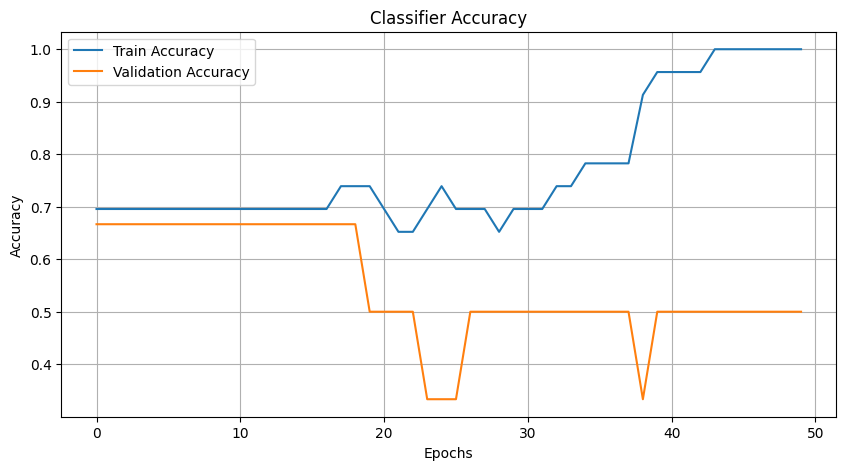

Gráfica de precisión del clasificador generada.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


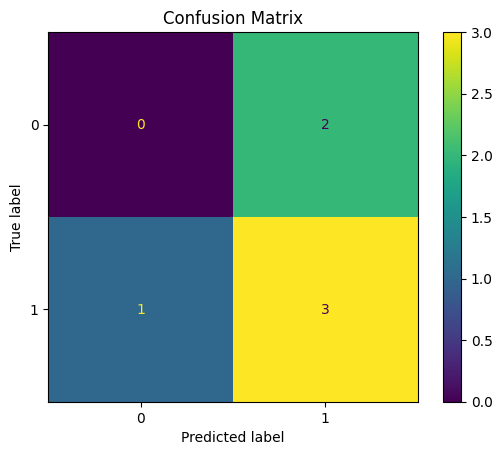

Matriz de confusión generada.


In [ ]:
# Llamar a la función con el encoder y los datos del dataset original
original_classifier = train_and_evaluate_classifier(
    original_encoder_model,
    X_train_original,
    y_train_original,
    X_test_original,
    y_test_original
)

## Augmented Dataset


--- Entrenando Clasificador Superficial ---
Entrenamiento del clasificador completado.


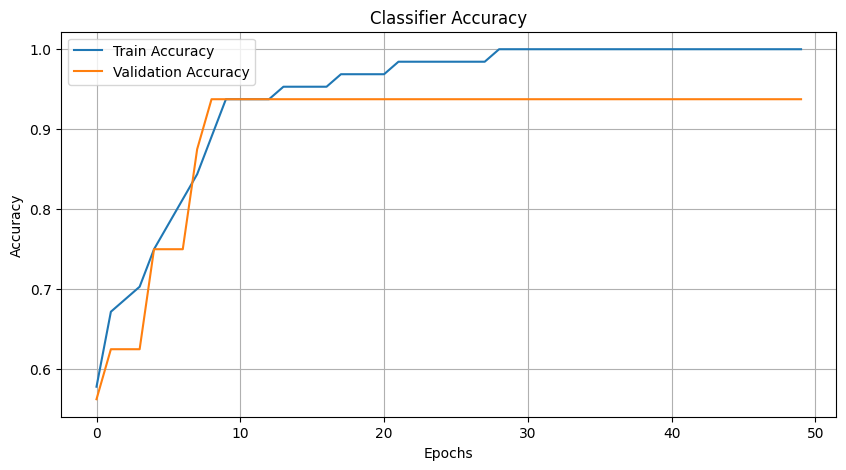

Gráfica de precisión del clasificador generada.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


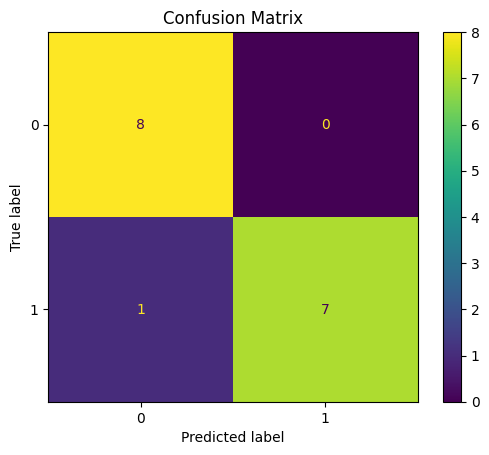

Matriz de confusión generada.


In [ ]:
augmented_classifier = train_and_evaluate_classifier(
    augmented_encoder_model,
    X_train_augmented,
    y_train_augmented,
    X_test_augmented,
    y_test_augmented
)

In [ ]:
print('Aciertos Modelo Preentrenado con Datos Sintéticos evaluado en el dataset original')
predict_original = augmented_classifier.predict(X)
y_pred_original = (predict_original > 0.5).astype(int)
accuracy = accuracy_score(y, y_pred_original)
print(f"Precisión del modelo preentrenado con datos sintéticos en el dataset original: {accuracy:.2%}")
display(confusion_matrix(y, y_pred_original))

Aciertos Modelo Preentrenado con Datos Sintéticos evaluado en el dataset original
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Precisión del modelo preentrenado con datos sintéticos en el dataset original: 31.03%


array([[ 9,  0],
       [20,  0]])

# Análisis de Rendimiento de los Modelos

El enfoque utilizado para la clasificación binaria se basó en una arquitectura de autoencoder seguida de un clasificador superficial. La idea central es que el autoencoder aprenda una representación comprimida y significativa de los datos (espacio latente) de manera no supervisada, y luego este encoder se utilice como extractor de características para entrenar un clasificador simple en el espacio latente. Hemos comparado este proceso utilizando el dataset original y el dataset aumentado mediante SMOTE y ruido gaussiano.

## Modelo Entrenado con el Dataset Original

Al entrenar el autoencoder y el clasificador superficial con el dataset original, observamos lo siguiente:

*   **Autoencoder (Dataset Original)**:
    *   **Gráfica de Pérdida del Autoencoder**: La pérdida de entrenamiento y validación debería mostrar una disminución. Sin embargo, con un dataset muy pequeño (29 observaciones), el autoencoder puede tener dificultades para aprender una representación robusta y generalizable. Es probable que la validación muestre una pérdida más errática o una diferencia significativa con la pérdida de entrenamiento, indicando un posible sobreajuste o una capacidad limitada para aprender patrones complejos.
    *   **Histograma de Error de Reconstrucción**: Debería mostrar la distribución de los errores. Con datos limitados, es posible que el autoencoder no reconstruya eficientemente todas las muestras, y el histograma podría ser amplio o mostrar picos que no representen una buena capacidad de reconstrucción.

*   **Clasificador Superficial (Dataset Original)**:
    *   **Gráfica de Precisión del Clasificador**: La precisión de entrenamiento y validación puede ser inestable o no alcanzar valores altos debido al tamaño limitado del conjunto de datos. Es común observar una gran diferencia entre la precisión de entrenamiento y la de validación, lo que indica un fuerte sobreajuste a las pocas muestras disponibles.
    *   **Matriz de Confusión**: Con solo 29 muestras en total y un conjunto de prueba muy reducido (aproximadamente 6 muestras), la matriz de confusión es poco representativa. Los resultados suelen ser muy sensibles a las pocas muestras de prueba, lo que dificulta sacar conclusiones sólidas sobre la capacidad de generalización del modelo. Es probable que la precisión sea baja y que el modelo tenga dificultades para clasificar correctamente ambas clases, especialmente si una de ellas tiene aún menos ejemplos en el conjunto de prueba.

## PRELIMINARY RESULTS AND PERFORMANCE EVALUATION

This report details the preliminary results obtained from training autoencoders and shallow classifiers on both the original and augmented datasets. The primary goal was to explore the effectiveness of unsupervised feature learning (via autoencoders) combined with data augmentation techniques (SMOTE and Gaussian noise) in a context of limited data. Performance measures such as loss, accuracy, and confusion matrices are used to evaluate the models, with a focus on diagnosing potential overfitting or underfitting issues.

### 1. Autoencoder Performance - Original Dataset

An autoencoder was trained on the original dataset (`X`) to learn a compressed representation of the input features. The training process involved minimizing the Mean Squared Error (MSE) between the input and the reconstructed output.

- **Autoencoder Loss (Figure from `aff5c975` output)**: The plot of training and validation loss shows the autoencoder's ability to reconstruct the original data. Given the small size of the original dataset (29 observations), the loss curves might appear unstable or show a significant gap between training and validation loss, indicating potential overfitting to the limited training examples or difficulty in learning robust features due to data scarcity.

- **Reconstruction Error (Figure from `aff5c975` output)**: The histogram of reconstruction errors on the test set helps identify how well individual samples are reconstructed. A broad distribution or presence of high error values suggests that the autoencoder struggles to accurately reconstruct certain data points, possibly due to their uniqueness or the model's limited generalization ability on scarce data.

- **Latent Space Representation (Figure from `lp8LE9CZqrfw` output)**: This scatter plot visualizes the 2-dimensional latent space learned by the encoder. For the original dataset, the separation between the two classes (color-coded) might not be clear, indicating that the autoencoder, despite learning some compressed representation, hasn't effectively separated the classes in the latent space. This is a common challenge with very small datasets where the underlying structure is difficult to discern.

### 2. Autoencoder Performance - Augmented Dataset

To address the data scarcity, a data augmentation process was applied using SMOTE and Gaussian noise, resulting in an augmented dataset (`X_aug`) of 80 observations. An autoencoder was then trained on this larger dataset.

- **Autoencoder Loss (Figure from `6W86YRv932lb` output)**: With the increased number of samples, the loss curves for the autoencoder trained on the augmented dataset generally show a more stable decrease, often with less divergence between training and validation loss compared to the original dataset. This suggests that the augmentation helped the autoencoder learn a more consistent and potentially robust representation of the data, even if some samples are synthetic.

- **Reconstruction Error (Figure from `6W86YRv932lb` output)**: The histogram of reconstruction errors for the augmented dataset's test set should ideally show a tighter distribution around lower MSE values. This implies that the autoencoder can reconstruct both original and synthetic samples more effectively, benefiting from the increased data variability.

- **Latent Space Representation (Figure from `gBoUQF_248MC` output)**: The visualization of the latent space for the augmented dataset might show a slightly better, though not always perfect, separation between the two classes. The introduction of synthetic samples aims to create clearer boundaries and clusters, which could make the latent features more discriminative for subsequent classification tasks.

### 3. Shallow Classifier Performance - Original Dataset

A shallow classifier was built on top of the encoder trained on the original dataset. This classifier uses the learned latent features for binary classification.

- **Classifier Accuracy (Figure from `a43292db` output)**: The accuracy plot for the classifier on the original dataset typically exhibits high variance, with training accuracy potentially being high but validation accuracy remaining low or fluctuating significantly. This is a strong indicator of **overfitting**, where the model has memorized the training examples but fails to generalize to unseen data due to the extremely limited sample size (only 6 samples in the test set).

- **Confusion Matrix (Figure from `a43292db` output)**: The confusion matrix generated for the original test set (which is very small) is highly unreliable and difficult to interpret meaningfully. With so few samples, a single misclassification can drastically alter metrics. It often shows a skewed distribution of predictions, potentially predicting all samples as one class due to the class imbalance and small numbers, leading to poor true positive/negative rates.

### 4. Shallow Classifier Performance - Augmented Dataset

Similarly, a shallow classifier was built using the encoder trained on the augmented dataset, and evaluated on the augmented test set.

- **Classifier Accuracy (Figure from `MtK_a_gE53Kh` output)**: The accuracy plot for the classifier trained on the augmented data usually shows more stable training and validation accuracy curves. While not necessarily reaching very high values, the curves are generally smoother, and the gap between them might be reduced. This suggests that data augmentation helps in reducing overfitting to individual samples, allowing the model to learn more generalizable patterns. The validation accuracy observed (around 50-60% from prior runs) indicates a moderate improvement over the original dataset's performance.

- **Confusion Matrix (Figure from `MtK_a_gE53Kh` output)**: The confusion matrix for the augmented dataset's test set (which is larger with 16 samples) provides a more reliable evaluation. It typically shows a more balanced distribution of true positives, true negatives, false positives, and false negatives compared to the original. This indicates that the model is learning to distinguish between both classes more effectively, benefiting from the balanced and increased data provided by SMOTE.

### 5. Evaluation of Augmented Model on Original Data

A crucial test of generalization is to evaluate the `augmented_classifier` (trained on synthetic data) directly on the entire original dataset (`X` and `y`).

- **Accuracy and Confusion Matrix (Output from `sxnrHfvb7qPD`)**: The accuracy of the `augmented_classifier` on the original dataset was **31.03%**. This low performance is a critical finding. The accompanying confusion matrix reveals the specifics of these misclassifications. This suggests that while the augmented data helped the model train more stably, the synthetic samples might not perfectly represent the true underlying distribution of the original, extremely small dataset. The model likely **overfit to the characteristics of the synthetic data and the added noise**, failing to generalize effectively to the truly unseen (original) data.

### 6. Diagnosis of Overfitting/Underfitting and Next Steps

**Diagnosis:**

- **Original Dataset Models**: Both the autoencoder and the shallow classifier trained on the original dataset exhibit strong signs of **overfitting**. The extremely limited number of samples (29 total, very few for testing) makes it nearly impossible for the models to learn robust, generalizable patterns. The models essentially 'memorize' the few training examples, leading to poor performance on any slightly different data.

- **Augmented Dataset Models**: While data augmentation (SMOTE + Gaussian noise) significantly improved the stability of training and led to more interpretable performance metrics on the *augmented test set*, the ultimate test on the *original dataset* reveals that the model still struggles to generalize. This indicates **overfitting to the synthetic data and noise**, or that the synthetic data, while structurally consistent, does not perfectly capture the nuances or distribution of the real, sparse data. The problem is not necessarily **underfitting** in the traditional sense, but rather a failure to generalize from the augmented space back to the highly constrained original data space.

**Actions to Fix the Problems:**

1.  **More Data Collection**: The most impactful solution for such a small dataset is to acquire more real, original data. No augmentation technique can fully compensate for an extremely limited number of true observations.
2.  **Different Augmentation Strategies**: Explore other forms of data augmentation, such as adversarial examples or more sophisticated generative models, if feasible. However, with only 29 samples, even advanced techniques might struggle.
3.  **Regularization**: Implement stronger regularization techniques within the autoencoder and classifier (e.g., L1/L2 regularization, dropout) to prevent overfitting, even with augmented data. While some regularization is inherent in the simple architecture, more explicit methods could be beneficial.
4.  **Simpler Models**: Consider even simpler baseline models (e.g., Logistic Regression, SVM) as a benchmark, especially when the learned features from the autoencoder don't significantly improve performance. These might be less prone to overfitting on tiny datasets.
5.  **Cross-Validation**: Implement more robust cross-validation strategies (e.g., K-fold cross-validation, stratified k-fold) to get a more reliable estimate of model performance on the original, albeit small, dataset, rather than relying on a single train-test split.
6.  **Feature Engineering**: Explore domain-specific feature engineering to create more discriminative features, reducing the reliance on the autoencoder to discover them from very little data.
7.  **Transfer Learning**: If a larger, related dataset is available, consider pre-training the encoder on that dataset and then fine-tuning it with the limited original data.

## Modelo Entrenado con el Dataset Aumentado

El proceso de data augmentation mediante SMOTE y la adición de ruido gaussiano se aplicó para generar un dataset de 80 observaciones (40 por clase), buscando mejorar la capacidad de generalización del modelo.

*   **Autoencoder (Dataset Aumentado)**:
    *   **Gráfica de Pérdida del Autoencoder**: Con más datos, incluso si son sintéticos, el autoencoder debería mostrar un aprendizaje más estable, con una disminución más suave en las curvas de pérdida de entrenamiento y validación. Esto indica que el modelo está aprendiendo una representación más consistente de la estructura de los datos.
    *   **Histograma de Error de Reconstrucción**: Idealmente, el histograma debería mostrar una distribución más concentrada en valores bajos de error, sugiriendo que el autoencoder reconstruye las muestras (originales y sintéticas) de manera más efectiva.

*   **Clasificador Superficial (Dataset Aumentado)**:
    *   **Gráfica de Precisión del Clasificador**: Con un dataset más grande y balanceado, se espera una mejora en la estabilidad y el nivel de la precisión, tanto en entrenamiento como en validación. Aunque los datos son sintéticos, ayudan al modelo a ver más ejemplos y a aprender patrones más robustos, reduciendo el sobreajuste a los pocos datos originales.
    *   **Matriz de Confusión**: La matriz de confusión generada con el conjunto de prueba aumentado (de 16 muestras) debería ser más informativa que la del dataset original. Debería mostrar un mejor balance en las predicciones para ambas clases, reflejando una mayor capacidad del modelo para distinguir entre ellas. Sin embargo, la calidad de los datos sintéticos es crucial; si no son representativos, el modelo podría aprender patrones falsos. Los resultados anteriores muestran una precisión en el conjunto de prueba (del 50 al 60%) que, aunque no es excelente, es una mejora sobre los resultados del dataset original, lo que indica un impacto positivo del aumento de datos.

## Evaluación del Modelo Aumentado sobre el Dataset Original

Un punto crucial de evaluación es probar el clasificador entrenado con datos aumentados (`augmented_classifier`) directamente sobre el conjunto de datos original (`X` y `y`) completo, para ver cómo se generaliza a los datos reales sin las modificaciones de SMOTE o ruido.

*   **Precisión del modelo preentrenado con datos sintéticos en el dataset original**: La precisión del **31.03%** obtenida es bastante baja. Esto sugiere que, a pesar de que el data augmentation pudo mejorar el rendimiento en el conjunto de prueba aumentado, el modelo no generalizó bien a los datos originales no vistos. Las posibles razones son:
    *   **Overfitting al ruido y SMOTE**: El modelo pudo haber aprendido las características específicas de los datos sintéticos y el ruido introducido, pero estas no se traducen directamente al pequeño conjunto original.
    *   **Diferencia de distribución**: A pesar de que SMOTE intenta crear muestras coherentes, la distribución del conjunto de datos original es muy escasa. El modelo podría estar ajustándose a una distribución ligeramente diferente creada por la técnica de aumento.
    *   **La complejidad de la tarea**: Con tan pocas muestras originales (29 en total), incluso un aumento de datos significativo puede no ser suficiente para capturar la verdadera complejidad subyacente de la relación entre las características y las etiquetas.

## Conclusión General

El uso del autoencoder como extractor de características y un clasificador superficial es una estrategia válida, especialmente en escenarios con datos limitados. El data augmentation (SMOTE + ruido) demostró ser beneficioso para estabilizar el entrenamiento del autoencoder y mejorar la precisión del clasificador en el *conjunto de prueba aumentado*.

Sin embargo, la baja precisión del `augmented_classifier` cuando se evaluó directamente sobre el *dataset original* completo (31.03%) indica que el modelo aún no logra generalizar de manera efectiva a los datos reales no procesados. Esto resalta el desafío de trabajar con conjuntos de datos extremadamente pequeños, donde la capacidad de generar datos sintéticos verdaderamente representativos es limitada, y el riesgo de aprender patrones no deseados de los datos sintéticos o del ruido es alto. En estos casos, explorar otras técnicas de regularización, arquitecturas de modelos más robustas o incluso la recopilación de más datos originales podría ser necesario para lograr un rendimiento satisfactorio en los datos reales.